<a href="https://colab.research.google.com/github/RheaMimiCarillo/skillspire-ai-ml/blob/main/Python___SQL_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PART 1

1. Import the libraries

In [ ]:
%pip install matplotlib
%pip install pandas
%pip install db-sqlite3
%pip install ipython sql
%pip install jupysql

ERROR: Could not find a version that satisfies the requirement sqlite3 (from versions: none)
ERROR: No matching distribution found for sqlite3
/usr/bin/python3


In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

2. Import the csv file 'Survey.csv' into df

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Survey.csv to Survey.csv


In [ ]:
df = pd.read_csv('Survey.csv')

df.head()

,Timestamp,Name,Age,Sex,Mobile Number (09xxxxxxxxx):,Are you from Bulacan?,Do you live with an extended family (with grandmother/aunt/and such)?,How many members are currently living in your house/household?,Are there students in your household?,How many members of your household contribute to the bills?,...,Please tick if you own these appliances (choose all possible),Month A,Month B,Month C,How much?,How often?,How many? (Students in your household),Do they use any of the following? (choose as many),Choose among the following: [How often do you struggle in finding money to pay for the electric bill?],Choose among the following: [How often do you fail to pay the monthly electric bill?]
0,2022/05/11 8:37:38 PM GMT+8,NaN,21.0,Male,NaN,Yes,No,5.0,Yes,2.0,...,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Higher than Php3000,Monthly,2,Laptop;Smart Phone,Sometimes,Sometimes
1,2022/05/11 8:37:55 PM GMT+8,NaN,20.0,Male,NaN,Yes,No,3.0,Yes,3.0,...,Air Conditioner;Desktop Computer;Rice Cooker,2500.0,3004,2752,NaN,NaN,2,Laptop;Desktop Computer;Smart Phone,Never,Never
2,2022/05/11 8:40:50 PM GMT+8,NaN,21.0,Male,NaN,Yes,No,5.0,Yes,3.0,...,TV;Refrigerator;Washing Machine;Desktop Computer,5000.0,5504,5252,Higher than Php3000,Yearly,2,Laptop;Desktop Computer;Smart Phone,Very Often,Sometimes
3,2022/05/11 8:44:20 PM GMT+8,NaN,20.0,Male,NaN,Yes,No,6.0,Yes,2.0,...,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Php1000-Php1999,Occasionally ( Not regularly),4,Laptop;Smart Phone,Sometimes,Never
4,2022/05/11 8:57:26 PM GMT+8,NaN,20.0,Female,NaN,Yes,No,4.0,Yes,2.0,...,Air Conditioner;TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser,2800.0,3304,3052,NaN,NaN,2,Laptop;Tablet;Smart Phone,Sometimes,Never


In [ ]:
# Inspecting column names
df.columns.tolist()

['Timestamp',
 'Name',
 'Age',
 'Sex',
 'Mobile Number (09xxxxxxxxx):',
 'Are you from Bulacan?',
 'Do you live with an extended family (with grandmother/aunt/and such)?',
 'How many members are currently living in your house/household?',
 'Are there students in your household?',
 'How many members of your household contribute to the bills?',
 'How much is your household’s accumulated salary per month?',
 'Does your household get occasional financial assistance other than the salary included in the section above? (ex. Padala and scholarship)',
 'How much is your household’s budget for electricity each month?',
 'Please tick if you own these appliances (choose all possible)',
 'Month A',
 'Month B',
 'Month C',
 'How much?',
 'How often?',
 'How many? (Students in your household)',
 'Do they use any of the following? (choose as many)',
 'Choose among the following: [How often do you struggle in finding money to pay for the electric bill?]',
 'Choose among the following: [How often do yo

3. Connect to a database, name the database 'Survey_Database.db'

In [ ]:
conn = sqlite3.connect('Survey_Database.db')

cursor = conn.cursor()

4. Add your dataframe to the database. Name the table 'Initial_Table'

In [ ]:
df.to_sql("Initial_Table", conn, index=False, if_exists="replace")

116

5. Check column names

In [ ]:
columns = pd.read_sql_query(
    "PRAGMA table_info('Initial_Table');",
    conn
)

columns[["cid", "name"]]

,cid,name
0,0,Timestamp
1,1,Name
2,2,Age
3,3,Sex
4,4,Mobile Number (09xxxxxxxxx):
5,5,Are you from Bulacan?
6,6,Do you live with an extended family (with grandmother/aunt/and such)?
7,7,How many members are currently living in your house/household?
8,8,Are there students in your household?
9,9,How many members of your household contribute to the bills?


6. Query: Make a table 'Initial_Table2' without the columns, timestamp, name, mobile number.

In [ ]:
# Age
# Sex
# Are you from Bulacan?
# Do you live with an extended family (with grandmother/aunt/and such)?
# How many members are currently living in your house/household?
# Are there students in your household?
# How many members of your household contribute to the bills?
# How much is your household’s accumulated salary per month?
# Does your household get occasional financial assistance other than the salary included in the section above? (ex. Padala and scholarship)
# How much is your household’s budget for electricity each month?
# Please tick if you own these appliances (choose all possible)
# Month A
# Month B
# Month C
# How much?
# How often?
# How many? (Students in your household)
# Do they use any of the following? (choose as many)
# Choose among the following: [How often do you struggle in finding money to pay for the electric bill?]
# Choose among the following: [How often do you fail to pay the monthly electric bill?]

exclude_these = {"Timestamp", "Name", "Mobile Number (09xxxxxxxxx):"}

all_columns = df.columns.tolist()
all_columns

['Timestamp',
 'Name',
 'Age',
 'Sex',
 'Mobile Number (09xxxxxxxxx):',
 'Are you from Bulacan?',
 'Do you live with an extended family (with grandmother/aunt/and such)?',
 'How many members are currently living in your house/household?',
 'Are there students in your household?',
 'How many members of your household contribute to the bills?',
 'How much is your household’s accumulated salary per month?',
 'Does your household get occasional financial assistance other than the salary included in the section above? (ex. Padala and scholarship)',
 'How much is your household’s budget for electricity each month?',
 'Please tick if you own these appliances (choose all possible)',
 'Month A',
 'Month B',
 'Month C',
 'How much?',
 'How often?',
 'How many? (Students in your household)',
 'Do they use any of the following? (choose as many)',
 'Choose among the following: [How often do you struggle in finding money to pay for the electric bill?]',
 'Choose among the following: [How often do yo

In [ ]:
for col_name in exclude_these:
  all_columns.remove(col_name)

In [ ]:
# confirming that excluded columns are actually got excluded
missing = exclude_these - set(all_columns)
print("Columns missing from query: ", missing)

Columns missing from query:  {'Timestamp', 'Name', 'Mobile Number (09xxxxxxxxx):'}


In [ ]:
# turning column name list into a string for the query
all_columns_string = ', '.join([f'"{col}"' for col in all_columns])

all_columns_string

'"Age", "Sex", "Are you from Bulacan?", "Do you live with an extended family (with grandmother/aunt/and such)?", "How many members are currently living in your house/household?", "Are there students in your household?", "How many members of your household contribute to the bills?", "How much is your household’s accumulated salary per month?", "Does your household get occasional financial assistance other than the salary included in the section above? (ex. Padala and scholarship)", "How much is your household’s budget for electricity each month?", "Please tick if you own these appliances (choose all possible)", "Month A", "Month B", "Month C", "How much?", "How often?", "How many? (Students in your household)", "Do they use any of the following? (choose as many)", "Choose among the following: [How often do you struggle in finding money to pay for the electric bill?]", "Choose among the following: [How often do you fail to pay the monthly electric bill?]"'

In [ ]:
# double checking that the query looks right before sending it
the_actual_query = f"""
  SELECT
    {all_columns_string}
  FROM Initial_Table
"""

the_actual_query

'\n  SELECT\n    "Age", "Sex", "Are you from Bulacan?", "Do you live with an extended family (with grandmother/aunt/and such)?", "How many members are currently living in your house/household?", "Are there students in your household?", "How many members of your household contribute to the bills?", "How much is your household’s accumulated salary per month?", "Does your household get occasional financial assistance other than the salary included in the section above? (ex. Padala and scholarship)", "How much is your household’s budget for electricity each month?", "Please tick if you own these appliances (choose all possible)", "Month A", "Month B", "Month C", "How much?", "How often?", "How many? (Students in your household)", "Do they use any of the following? (choose as many)", "Choose among the following: [How often do you struggle in finding money to pay for the electric bill?]", "Choose among the following: [How often do you fail to pay the monthly electric bill?]"\n  FROM Initial_

In [ ]:
# The actual Initial_Table2
Initial_Table2 = pd.read_sql_query(the_actual_query, conn)
Initial_Table2.to_sql("Initial_Table2", conn, index=False, if_exists="replace")

Initial_Table2

,Age,Sex,Are you from Bulacan?,Do you live with an extended family (with grandmother/aunt/and such)?,How many members are currently living in your house/household?,Are there students in your household?,How many members of your household contribute to the bills?,How much is your household’s accumulated salary per month?,Does your household get occasional financial assistance other than the salary included in the section above? (ex. Padala and scholarship),How much is your household’s budget for electricity each month?,Please tick if you own these appliances (choose all possible),Month A,Month B,Month C,How much?,How often?,How many? (Students in your household),Do they use any of the following? (choose as many),Choose among the following: [How often do you struggle in finding money to pay for the electric bill?],Choose among the following: [How often do you fail to pay the monthly electric bill?]
0,21.0,Male,Yes,No,5.0,Yes,2.0,"Between Php 21,194 and Php 43, 828",Yes,1000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Higher than Php3000,Monthly,2,Laptop;Smart Phone,Sometimes,Sometimes
1,20.0,Male,Yes,No,3.0,Yes,3.0,"Between Php 21,194 and Php 43, 828",No,3000.0,Air Conditioner;Desktop Computer;Rice Cooker,2500.0,3004,2752,None,None,2,Laptop;Desktop Computer;Smart Phone,Never,Never
2,21.0,Male,Yes,No,5.0,Yes,3.0,"Less than Php 21,194",Yes,5500.0,TV;Refrigerator;Washing Machine;Desktop Computer,5000.0,5504,5252,Higher than Php3000,Yearly,2,Laptop;Desktop Computer;Smart Phone,Very Often,Sometimes
3,20.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",Yes,2000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Php1000-Php1999,Occasionally ( Not regularly),4,Laptop;Smart Phone,Sometimes,Never
4,20.0,Female,Yes,No,4.0,Yes,2.0,"Less than Php 21,194",No,3000.0,Air Conditioner;TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser,2800.0,3304,3052,None,None,2,Laptop;Tablet;Smart Phone,Sometimes,Never
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,22.0,Female,Yes,Yes,6.0,Yes,3.0,"Between Php 21,194 and Php 43, 828",Yes,3000.0,Air Conditioner;TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser,2500.0,3004,2752,Higher than Php3000,Monthly,2,Laptop;Tablet;Smart Phone,Never,Never
112,19.0,Male,No,None,NaN,None,NaN,None,None,NaN,None,NaN,504,252,None,None,None,None,None,None
113,151.0,Female,Yes,Yes,7.0,Yes,4.0,"Less than Php 21,194",No,1000.0,TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser,800.0,1304,1052,None,None,2,Laptop;Smart Phone,Sometimes,Sometimes
114,2.0,Female,Yes,No,7.0,Yes,2.0,"Less than Php 21,194",No,2000.0,TV;Refrigerator;Desktop Computer,1634.0,2138,1886,None,None,2,Laptop;Desktop Computer;Tablet;Smart Phone,Sometimes,Sometimes


7. Query: Only retrieve data of respondents from Bulacan.

In [ ]:
bulacan_query = """
  SELECT * FROM Initial_Table2
  WHERE "Are you from Bulacan?" = "Yes";
"""
Main_Table = pd.read_sql_query(bulacan_query, conn)

8. Make a table from the query in item 7, call it 'Main_Table'

In [ ]:
Main_Table.to_sql("Main_Table", conn, index=False, if_exists="replace")

Main_Table

,Age,Sex,Are you from Bulacan?,Do you live with an extended family (with grandmother/aunt/and such)?,How many members are currently living in your house/household?,Are there students in your household?,How many members of your household contribute to the bills?,How much is your household’s accumulated salary per month?,Does your household get occasional financial assistance other than the salary included in the section above? (ex. Padala and scholarship),How much is your household’s budget for electricity each month?,Please tick if you own these appliances (choose all possible),Month A,Month B,Month C,How much?,How often?,How many? (Students in your household),Do they use any of the following? (choose as many),Choose among the following: [How often do you struggle in finding money to pay for the electric bill?],Choose among the following: [How often do you fail to pay the monthly electric bill?]
0,21.0,Male,Yes,No,5.0,Yes,2.0,"Between Php 21,194 and Php 43, 828",Yes,1000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Higher than Php3000,Monthly,2,Laptop;Smart Phone,Sometimes,Sometimes
1,20.0,Male,Yes,No,3.0,Yes,3.0,"Between Php 21,194 and Php 43, 828",No,3000.0,Air Conditioner;Desktop Computer;Rice Cooker,2500.0,3004,2752,None,None,2,Laptop;Desktop Computer;Smart Phone,Never,Never
2,21.0,Male,Yes,No,5.0,Yes,3.0,"Less than Php 21,194",Yes,5500.0,TV;Refrigerator;Washing Machine;Desktop Computer,5000.0,5504,5252,Higher than Php3000,Yearly,2,Laptop;Desktop Computer;Smart Phone,Very Often,Sometimes
3,20.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",Yes,2000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Php1000-Php1999,Occasionally ( Not regularly),4,Laptop;Smart Phone,Sometimes,Never
4,20.0,Female,Yes,No,4.0,Yes,2.0,"Less than Php 21,194",No,3000.0,Air Conditioner;TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser,2800.0,3304,3052,None,None,2,Laptop;Tablet;Smart Phone,Sometimes,Never
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,22.0,Female,Yes,Yes,3.0,Yes,1.0,"Less than Php 21,194",No,1500.0,Air Conditioner;TV;Refrigerator;Washing Machine;Desktop Computer;Rice Cooker,1500.0,2004,1752,None,None,2,Laptop;Desktop Computer;Smart Phone,Often,Sometimes
108,22.0,Female,Yes,Yes,6.0,Yes,3.0,"Between Php 21,194 and Php 43, 828",Yes,3000.0,Air Conditioner;TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser,2500.0,3004,2752,Higher than Php3000,Monthly,2,Laptop;Tablet;Smart Phone,Never,Never
109,151.0,Female,Yes,Yes,7.0,Yes,4.0,"Less than Php 21,194",No,1000.0,TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser,800.0,1304,1052,None,None,2,Laptop;Smart Phone,Sometimes,Sometimes
110,2.0,Female,Yes,No,7.0,Yes,2.0,"Less than Php 21,194",No,2000.0,TV;Refrigerator;Desktop Computer,1634.0,2138,1886,None,None,2,Laptop;Desktop Computer;Tablet;Smart Phone,Sometimes,Sometimes


9. Query: Retrieve responses with students in household

In [ ]:
students_query = """
  SELECT * FROM Main_Table
  WHERE "Are there students in your household?" = "Yes"
"""

With_Students = pd.read_sql_query(students_query, conn)

10. Make a table from the Query in item 9. Call it 'With_Students'

In [ ]:
With_Students.to_sql("With_Students", conn, index=False, if_exists="replace")

With_Students

,Age,Sex,Are you from Bulacan?,Do you live with an extended family (with grandmother/aunt/and such)?,How many members are currently living in your house/household?,Are there students in your household?,How many members of your household contribute to the bills?,How much is your household’s accumulated salary per month?,Does your household get occasional financial assistance other than the salary included in the section above? (ex. Padala and scholarship),How much is your household’s budget for electricity each month?,Please tick if you own these appliances (choose all possible),Month A,Month B,Month C,How much?,How often?,How many? (Students in your household),Do they use any of the following? (choose as many),Choose among the following: [How often do you struggle in finding money to pay for the electric bill?],Choose among the following: [How often do you fail to pay the monthly electric bill?]
0,21.0,Male,Yes,No,5.0,Yes,2.0,"Between Php 21,194 and Php 43, 828",Yes,1000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Higher than Php3000,Monthly,2,Laptop;Smart Phone,Sometimes,Sometimes
1,20.0,Male,Yes,No,3.0,Yes,3.0,"Between Php 21,194 and Php 43, 828",No,3000.0,Air Conditioner;Desktop Computer;Rice Cooker,2500.0,3004,2752,None,None,2,Laptop;Desktop Computer;Smart Phone,Never,Never
2,21.0,Male,Yes,No,5.0,Yes,3.0,"Less than Php 21,194",Yes,5500.0,TV;Refrigerator;Washing Machine;Desktop Computer,5000.0,5504,5252,Higher than Php3000,Yearly,2,Laptop;Desktop Computer;Smart Phone,Very Often,Sometimes
3,20.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",Yes,2000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Php1000-Php1999,Occasionally ( Not regularly),4,Laptop;Smart Phone,Sometimes,Never
4,20.0,Female,Yes,No,4.0,Yes,2.0,"Less than Php 21,194",No,3000.0,Air Conditioner;TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser,2800.0,3304,3052,None,None,2,Laptop;Tablet;Smart Phone,Sometimes,Never
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,22.0,Female,Yes,Yes,3.0,Yes,1.0,"Less than Php 21,194",No,1500.0,Air Conditioner;TV;Refrigerator;Washing Machine;Desktop Computer;Rice Cooker,1500.0,2004,1752,None,None,2,Laptop;Desktop Computer;Smart Phone,Often,Sometimes
105,22.0,Female,Yes,Yes,6.0,Yes,3.0,"Between Php 21,194 and Php 43, 828",Yes,3000.0,Air Conditioner;TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser,2500.0,3004,2752,Higher than Php3000,Monthly,2,Laptop;Tablet;Smart Phone,Never,Never
106,151.0,Female,Yes,Yes,7.0,Yes,4.0,"Less than Php 21,194",No,1000.0,TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser,800.0,1304,1052,None,None,2,Laptop;Smart Phone,Sometimes,Sometimes
107,2.0,Female,Yes,No,7.0,Yes,2.0,"Less than Php 21,194",No,2000.0,TV;Refrigerator;Desktop Computer,1634.0,2138,1886,None,None,2,Laptop;Desktop Computer;Tablet;Smart Phone,Sometimes,Sometimes


11. Query: Retrieve responses from table 'With_Students' where students have at least a Laptop or a Desktop Computer

In [ ]:
# From column "Do they use any of the following? (choose as many)"
# Delimited by ";"

laptop_desktop_query = """
    SELECT *
    FROM With_Students
    WHERE "Do they use any of the following? (choose as many)" LIKE "%Laptop%"
       OR "Do they use any of the following? (choose as many)" LIKE "%Desktop Computer%";
"""

Students_With_Computer = pd.read_sql_query(
    laptop_desktop_query,
    conn
)

Students_With_Computer


,Age,Sex,Are you from Bulacan?,Do you live with an extended family (with grandmother/aunt/and such)?,How many members are currently living in your house/household?,Are there students in your household?,How many members of your household contribute to the bills?,How much is your household’s accumulated salary per month?,Does your household get occasional financial assistance other than the salary included in the section above? (ex. Padala and scholarship),How much is your household’s budget for electricity each month?,Please tick if you own these appliances (choose all possible),Month A,Month B,Month C,How much?,How often?,How many? (Students in your household),Do they use any of the following? (choose as many),Choose among the following: [How often do you struggle in finding money to pay for the electric bill?],Choose among the following: [How often do you fail to pay the monthly electric bill?]
0,21.0,Male,Yes,No,5.0,Yes,2.0,"Between Php 21,194 and Php 43, 828",Yes,1000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Higher than Php3000,Monthly,2,Laptop;Smart Phone,Sometimes,Sometimes
1,20.0,Male,Yes,No,3.0,Yes,3.0,"Between Php 21,194 and Php 43, 828",No,3000.0,Air Conditioner;Desktop Computer;Rice Cooker,2500.0,3004,2752,None,None,2,Laptop;Desktop Computer;Smart Phone,Never,Never
2,21.0,Male,Yes,No,5.0,Yes,3.0,"Less than Php 21,194",Yes,5500.0,TV;Refrigerator;Washing Machine;Desktop Computer,5000.0,5504,5252,Higher than Php3000,Yearly,2,Laptop;Desktop Computer;Smart Phone,Very Often,Sometimes
3,20.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",Yes,2000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Php1000-Php1999,Occasionally ( Not regularly),4,Laptop;Smart Phone,Sometimes,Never
4,20.0,Female,Yes,No,4.0,Yes,2.0,"Less than Php 21,194",No,3000.0,Air Conditioner;TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser,2800.0,3304,3052,None,None,2,Laptop;Tablet;Smart Phone,Sometimes,Never
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,22.0,Female,Yes,Yes,3.0,Yes,1.0,"Less than Php 21,194",No,1500.0,Air Conditioner;TV;Refrigerator;Washing Machine;Desktop Computer;Rice Cooker,1500.0,2004,1752,None,None,2,Laptop;Desktop Computer;Smart Phone,Often,Sometimes
85,22.0,Female,Yes,Yes,6.0,Yes,3.0,"Between Php 21,194 and Php 43, 828",Yes,3000.0,Air Conditioner;TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser,2500.0,3004,2752,Higher than Php3000,Monthly,2,Laptop;Tablet;Smart Phone,Never,Never
86,151.0,Female,Yes,Yes,7.0,Yes,4.0,"Less than Php 21,194",No,1000.0,TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser,800.0,1304,1052,None,None,2,Laptop;Smart Phone,Sometimes,Sometimes
87,2.0,Female,Yes,No,7.0,Yes,2.0,"Less than Php 21,194",No,2000.0,TV;Refrigerator;Desktop Computer,1634.0,2138,1886,None,None,2,Laptop;Desktop Computer;Tablet;Smart Phone,Sometimes,Sometimes


12. Show the existing tables in the current database.

In [ ]:
tables_query = """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table';
"""

tables = pd.read_sql_query(tables_query, conn)

tables

,name
0,With_Students
1,Main_Table


13. Close the connection

In [ ]:
cursor.close()
conn.close()

14. Call the database again, verify if we have the new tables.

In [ ]:
conn = sqlite3.connect("Survey_Database.db")
cursor = conn.cursor()

pd.read_sql_query(tables_query, conn)

,name
0,With_Students
1,Main_Table


15. Drop both of the Initial Tables

In [ ]:
cursor.execute("DROP TABLE IF EXISTS Initial_Table;")
cursor.execute("DROP TABLE IF EXISTS Initial_Table2;")

conn.commit()

pd.read_sql_query(tables_query, conn)

,name
0,With_Students
1,Main_Table


#PART 2

## OUR CONCLUSION SHOUD REVOLVE AROUND THE LOW INCOME HOUSEHOLDS EARNING LESS THAN PHP 21,194.

###1. FILTERING QUALIFIED RESPONDENTS

a. Query_Sample: Only retrieve respondents who belongs to the low income households. Use Main_Table

In [ ]:
Query_Sample = """
  SELECT *
  FROM Main_Table
  WHERE "How much is your household’s accumulated salary per month?" = "Less than Php 21,194"
"""

sample = pd.read_sql_query(Query_Sample, conn)
sample

,Age,Sex,Are you from Bulacan?,Do you live with an extended family (with grandmother/aunt/and such)?,How many members are currently living in your house/household?,Are there students in your household?,How many members of your household contribute to the bills?,How much is your household’s accumulated salary per month?,Does your household get occasional financial assistance other than the salary included in the section above? (ex. Padala and scholarship),How much is your household’s budget for electricity each month?,Please tick if you own these appliances (choose all possible),Month A,Month B,Month C,How much?,How often?,How many? (Students in your household),Do they use any of the following? (choose as many),Choose among the following: [How often do you struggle in finding money to pay for the electric bill?],Choose among the following: [How often do you fail to pay the monthly electric bill?]
0,21.0,Male,Yes,No,5.0,Yes,3.0,"Less than Php 21,194",Yes,5500.0,TV;Refrigerator;Washing Machine;Desktop Computer,5000.0,5504,5252,Higher than Php3000,Yearly,2,Laptop;Desktop Computer;Smart Phone,Very Often,Sometimes
1,20.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",Yes,2000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Php1000-Php1999,Occasionally ( Not regularly),4,Laptop;Smart Phone,Sometimes,Never
2,20.0,Female,Yes,No,4.0,Yes,2.0,"Less than Php 21,194",No,3000.0,Air Conditioner;TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser,2800.0,3304,3052,None,None,2,Laptop;Tablet;Smart Phone,Sometimes,Never
3,21.0,Female,Yes,Yes,7.0,Yes,4.0,"Less than Php 21,194",No,1000.0,TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser,800.0,1304,1052,None,None,2,Laptop;Smart Phone,Sometimes,Sometimes
4,21.0,Female,Yes,No,7.0,Yes,2.0,"Less than Php 21,194",No,2000.0,TV;Refrigerator;Desktop Computer,1634.0,2138,1886,None,None,2,Laptop;Desktop Computer;Tablet;Smart Phone,Sometimes,Sometimes
5,18.0,Male,Yes,No,3.0,Yes,2.0,"Less than Php 21,194",No,500.0,TV;Washing Machine;Rice Cooker,200.0,704,452,None,None,1,Laptop;Smart Phone,Sometimes,Sometimes
6,21.0,Female,Yes,Yes,7.0,Yes,2.0,"Less than Php 21,194",Yes,5000.0,Air Conditioner;TV;Washing Machine,5200.0,5704,5452,Php1000-Php1999,Occasionally ( Not regularly),1,Laptop;Smart Phone,Always,Sometimes
7,18.0,Male,Yes,Yes,6.0,Yes,3.0,"Less than Php 21,194",No,5000.0,Air Conditioner;TV;Refrigerator;Washing Machine;Desktop Computer;Rice Cooker,5000.0,5504,5252,None,None,1,Desktop Computer;Smart Phone,Sometimes,Never
8,21.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",No,2000.0,TV;Refrigerator;Washing Machine;Desktop Computer;Rice Cooker,1800.0,2304,2052,None,None,2,Desktop Computer,Sometimes,Sometimes
9,21.0,Male,Yes,Yes,7.0,Yes,1.0,"Less than Php 21,194",Yes,2500.0,TV;Refrigerator;Washing Machine;Desktop Computer;Rice Cooker,2000.0,2504,2252,Higher than Php3000,Yearly,3,Desktop Computer;Smart Phone,Sometimes,Sometimes


b. Make a table and call it 'sample' <br><br>
*--- > a "sample" refers to a subset of individuals or elements from a larger population that is selected for study.*

In [ ]:
sample.to_sql("sample", conn, index=False, if_exists="replace")

58

###2. Average Bill

a. Query_avg_bill: Add a column in sample, call it "avg_bill" and get the average of month a, month b, month c columns. Retrieve ALL information including the new column.

In [ ]:
Query_avg_bill = """
  SELECT *,
    ("Month A" + "Month B" + "Month C") / 3.0 AS avg_bill
  FROM sample;
"""

avg_bill_sample = pd.read_sql_query(Query_avg_bill, conn)

avg_bill_sample

,Age,Sex,Are you from Bulacan?,Do you live with an extended family (with grandmother/aunt/and such)?,How many members are currently living in your house/household?,Are there students in your household?,How many members of your household contribute to the bills?,How much is your household’s accumulated salary per month?,Does your household get occasional financial assistance other than the salary included in the section above? (ex. Padala and scholarship),How much is your household’s budget for electricity each month?,...,Month A,Month B,Month C,How much?,How often?,How many? (Students in your household),Do they use any of the following? (choose as many),Choose among the following: [How often do you struggle in finding money to pay for the electric bill?],Choose among the following: [How often do you fail to pay the monthly electric bill?],avg_bill
0,21.0,Male,Yes,No,5.0,Yes,3.0,"Less than Php 21,194",Yes,5500.0,...,5000.0,5504,5252,Higher than Php3000,Yearly,2,Laptop;Desktop Computer;Smart Phone,Very Often,Sometimes,5252.0
1,20.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",Yes,2000.0,...,1000.0,1504,1252,Php1000-Php1999,Occasionally ( Not regularly),4,Laptop;Smart Phone,Sometimes,Never,1252.0
2,20.0,Female,Yes,No,4.0,Yes,2.0,"Less than Php 21,194",No,3000.0,...,2800.0,3304,3052,None,None,2,Laptop;Tablet;Smart Phone,Sometimes,Never,3052.0
3,21.0,Female,Yes,Yes,7.0,Yes,4.0,"Less than Php 21,194",No,1000.0,...,800.0,1304,1052,None,None,2,Laptop;Smart Phone,Sometimes,Sometimes,1052.0
4,21.0,Female,Yes,No,7.0,Yes,2.0,"Less than Php 21,194",No,2000.0,...,1634.0,2138,1886,None,None,2,Laptop;Desktop Computer;Tablet;Smart Phone,Sometimes,Sometimes,1886.0
5,18.0,Male,Yes,No,3.0,Yes,2.0,"Less than Php 21,194",No,500.0,...,200.0,704,452,None,None,1,Laptop;Smart Phone,Sometimes,Sometimes,452.0
6,21.0,Female,Yes,Yes,7.0,Yes,2.0,"Less than Php 21,194",Yes,5000.0,...,5200.0,5704,5452,Php1000-Php1999,Occasionally ( Not regularly),1,Laptop;Smart Phone,Always,Sometimes,5452.0
7,18.0,Male,Yes,Yes,6.0,Yes,3.0,"Less than Php 21,194",No,5000.0,...,5000.0,5504,5252,None,None,1,Desktop Computer;Smart Phone,Sometimes,Never,5252.0
8,21.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",No,2000.0,...,1800.0,2304,2052,None,None,2,Desktop Computer,Sometimes,Sometimes,2052.0
9,21.0,Male,Yes,Yes,7.0,Yes,1.0,"Less than Php 21,194",Yes,2500.0,...,2000.0,2504,2252,Higher than Php3000,Yearly,3,Desktop Computer;Smart Phone,Sometimes,Sometimes,2252.0


b. Store the information we retrieved to our updated table, call it 'final_sample'

In [ ]:
avg_bill_sample.to_sql("final_sample", conn, index=False, if_exists="replace")

58

c. We can now drop columns Month A, Month B, and Month C.

In [ ]:
cursor.execute('ALTER TABLE final_sample DROP COLUMN "Month A";')
cursor.execute('ALTER TABLE final_sample DROP COLUMN "Month B";')
cursor.execute('ALTER TABLE final_sample DROP COLUMN "Month C";')

conn.commit()

d. final_sample: Retrieve all the information in final_sample to verify the column drops.

In [ ]:
final_sample = pd.read_sql_query(
    "SELECT * FROM final_sample;",
    conn
)

final_sample

,Age,Sex,Are you from Bulacan?,Do you live with an extended family (with grandmother/aunt/and such)?,How many members are currently living in your house/household?,Are there students in your household?,How many members of your household contribute to the bills?,How much is your household’s accumulated salary per month?,Does your household get occasional financial assistance other than the salary included in the section above? (ex. Padala and scholarship),How much is your household’s budget for electricity each month?,Please tick if you own these appliances (choose all possible),How much?,How often?,How many? (Students in your household),Do they use any of the following? (choose as many),Choose among the following: [How often do you struggle in finding money to pay for the electric bill?],Choose among the following: [How often do you fail to pay the monthly electric bill?],avg_bill
0,21.0,Male,Yes,No,5.0,Yes,3.0,"Less than Php 21,194",Yes,5500.0,TV;Refrigerator;Washing Machine;Desktop Computer,Higher than Php3000,Yearly,2,Laptop;Desktop Computer;Smart Phone,Very Often,Sometimes,5252.0
1,20.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",Yes,2000.0,TV;Refrigerator;Washing Machine,Php1000-Php1999,Occasionally ( Not regularly),4,Laptop;Smart Phone,Sometimes,Never,1252.0
2,20.0,Female,Yes,No,4.0,Yes,2.0,"Less than Php 21,194",No,3000.0,Air Conditioner;TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser,None,None,2,Laptop;Tablet;Smart Phone,Sometimes,Never,3052.0
3,21.0,Female,Yes,Yes,7.0,Yes,4.0,"Less than Php 21,194",No,1000.0,TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser,None,None,2,Laptop;Smart Phone,Sometimes,Sometimes,1052.0
4,21.0,Female,Yes,No,7.0,Yes,2.0,"Less than Php 21,194",No,2000.0,TV;Refrigerator;Desktop Computer,None,None,2,Laptop;Desktop Computer;Tablet;Smart Phone,Sometimes,Sometimes,1886.0
5,18.0,Male,Yes,No,3.0,Yes,2.0,"Less than Php 21,194",No,500.0,TV;Washing Machine;Rice Cooker,None,None,1,Laptop;Smart Phone,Sometimes,Sometimes,452.0
6,21.0,Female,Yes,Yes,7.0,Yes,2.0,"Less than Php 21,194",Yes,5000.0,Air Conditioner;TV;Washing Machine,Php1000-Php1999,Occasionally ( Not regularly),1,Laptop;Smart Phone,Always,Sometimes,5452.0
7,18.0,Male,Yes,Yes,6.0,Yes,3.0,"Less than Php 21,194",No,5000.0,Air Conditioner;TV;Refrigerator;Washing Machine;Desktop Computer;Rice Cooker,None,None,1,Desktop Computer;Smart Phone,Sometimes,Never,5252.0
8,21.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",No,2000.0,TV;Refrigerator;Washing Machine;Desktop Computer;Rice Cooker,None,None,2,Desktop Computer,Sometimes,Sometimes,2052.0
9,21.0,Male,Yes,Yes,7.0,Yes,1.0,"Less than Php 21,194",Yes,2500.0,TV;Refrigerator;Washing Machine;Desktop Computer;Rice Cooker,Higher than Php3000,Yearly,3,Desktop Computer;Smart Phone,Sometimes,Sometimes,2252.0


##Deriving Conclusions from final_sample

FIRST!! close the connection, we will use python for the rest of the conclusions.

In [ ]:
cursor.close()
conn.close()

ANSWER THE FOLLOWING QUESTIONS: <br>
use python through 'final_sample' dataframe we made a while ago

```python
# cheat sheet

# Count categories
final_sample["some column"].value_counts()

# Calculate mean
final_sample["avg_bill"].mean()

# Compare group averages
final_sample.groupby("some category")["avg_bill"].mean()

# Filter rows
final_sample[final_sample["some column"] == "Yes"]

# Make a pie chart
final_sample["some column"].value_counts().plot(kind="pie")

# Make a bar chart
final_sample["some column"].value_counts().plot(kind="bar")
```

###3. Extended family

a. How many low income households live with extended family?

In [ ]:
final_sample["Do you live with an extended family (with grandmother/aunt/and such)?"].value_counts()

,count
Do you live with an extended family (with grandmother/aunt/and such)?,
No,35
Yes,23


b. Make a pie chart showing the difference between the households living with extended family and those who do not. (ONLY PYTHON)

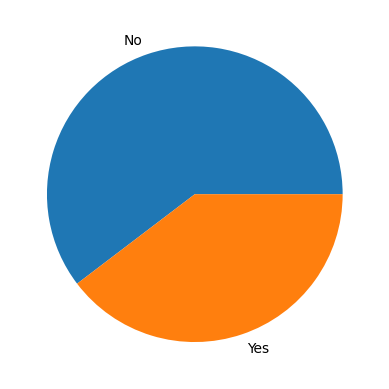

In [ ]:
final_sample["Do you live with an extended family (with grandmother/aunt/and such)?"].value_counts().plot(kind="pie")
plt.ylabel("")
plt.show()

###4. Students at home

a. How many households have students?

In [ ]:
final_sample["Are there students in your household?"].value_counts()

,count
Are there students in your household?,
Yes,57
No,1


b. Make a pie chart from it.

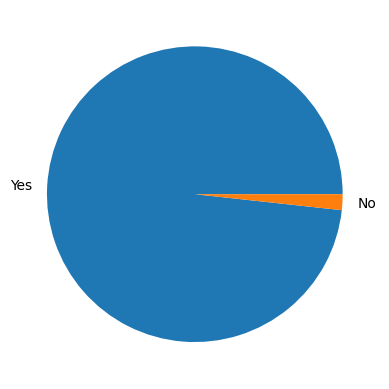

In [ ]:
final_sample["Are there students in your household?"].value_counts().plot(kind="pie")
plt.ylabel("")
plt.show()

###5. AVERAGE BILL / AVERAGE BUDGET

a. How much is the average bill of the low income households? call the variable 'avg_bill_household'

In [ ]:
avg_bill_household = final_sample["avg_bill"].mean()
print(f"Average bill of low income households: PHP {avg_bill_household.round(2)}")

Average bill of low income households: PHP 3498.95


b. How much is the average budget of the low income households? Call the variable 'avg_budget_household'.

In [ ]:
avg_budget_household = final_sample["How much is your household’s budget for electricity each month?"].mean()
print(f"Average budget of low income households: PHP {avg_budget_household.round(2)}")

Average budget of low income households: PHP 2327.09


c. Based on the numbers, what can you conclude?

**Answer:** The average electricity bill exceeds the average household budget. This means that households are operating on a deficit and can't make ends meet.

###6. AVERAGE BILL with students

a. What is the average bill of households with students at home? Use .groupby

```
# sample code from previous lecture

df[['Education',"Income"]].groupby("Education").mean()
```



In [ ]:
final_sample.groupby("Are there students in your household?")["avg_bill"].mean()

,avg_bill
Are there students in your household?,
No,1252.000000
Yes,3538.368421


b. What can you conclude from the information above? Note: This is a trick question.

**Answer:** There is only one household without students in final_sample, so drawing a conclusion would be misrepresenting the data.

###7. Struggle to find money.

a. How many households struggle to pay the bill always, very often, often, sometimes, and never?



```
.value_counts()
```



In [ ]:
final_sample["Choose among the following: [How often do you struggle in finding money to pay for the electric bill?]"].value_counts()

,count
Choose among the following: [How often do you struggle in finding money to pay for the electric bill?],
Sometimes,26
Always,11
Often,10
Very Often,8
Never,3


b. Make a bar chart

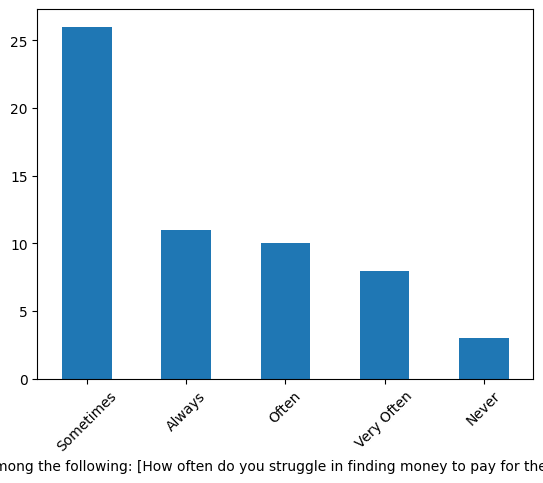

In [ ]:
final_sample["Choose among the following: [How often do you struggle in finding money to pay for the electric bill?]"].value_counts().plot(kind="bar")
plt.xticks(rotation=45)
plt.show()

###8. Fail to pay the bill

a. How many households struggle to pay the bill always, very often, often, sometimes, and never?



```
.value_counts()
```


In [ ]:
final_sample["Choose among the following: [How often do you fail to pay the monthly electric bill?]"].value_counts()

,count
Choose among the following: [How often do you fail to pay the monthly electric bill?],
Sometimes,31
Never,12
Often,9
Very Often,4
Always,2


b. Make a bar chart

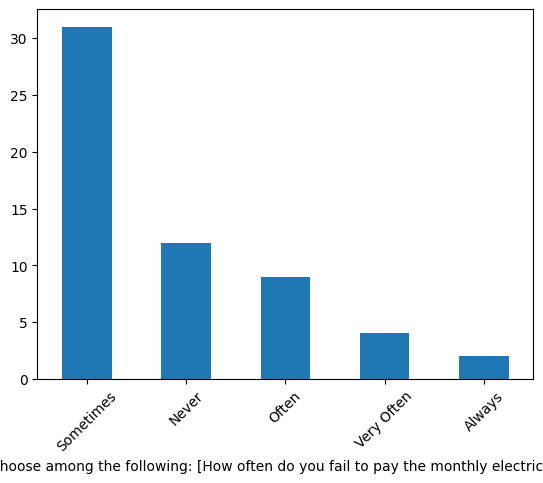

In [ ]:
final_sample["Choose among the following: [How often do you fail to pay the monthly electric bill?]"].value_counts().plot(kind="bar")
plt.xticks(rotation=45)
plt.show()

###9. You now may use SQL, or Python, whichever is more comfortable.

if you will use SQL, make sure to reconnect to the database THAT IS already in our directory. Careful with the spelling.


a. Count how many households have each of the essential appliances.

1. TV
2. Refrigerator
3. Rice Cooker
4. Washing Machine

<br>

also count how many households got the luxury of having these appliances.

1. Electric Water Dispenser
2. Air Conditioner

In [ ]:
# Essential Appliances
tv_count = final_sample["Please tick if you own these appliances (choose all possible)"].str.contains("TV", na=False).sum()
print(f"TV: {tv_count}")

fridge_count = final_sample["Please tick if you own these appliances (choose all possible)"].str.contains("Refrigerator", na=False).sum()
print(f"Refrigerator: {fridge_count}")

rice_cooker_count = final_sample["Please tick if you own these appliances (choose all possible)"].str.contains("Rice Cooker", na=False).sum()
print(f"Rice Cooker: {rice_cooker_count}")

washing_machine_count = final_sample["Please tick if you own these appliances (choose all possible)"].str.contains("Washing Machine", na=False).sum()
print(f"Washing Machine: {washing_machine_count}")

TV: 55
Refrigerator: 42
Rice Cooker: 33
Washing Machine: 51
Electric Water Dispenser: 8
Air Conditioner: 22


In [ ]:
# Luxury Appliances
water_dispenser_count = final_sample["Please tick if you own these appliances (choose all possible)"].str.contains("Electric Water Dispenser", na=False).sum()
print(f"Electric Water Dispenser: {water_dispenser_count}")

ac_count = final_sample["Please tick if you own these appliances (choose all possible)"].str.contains("Air Conditioner", na=False).sum()
print(f"Air Conditioner: {ac_count}")

Electric Water Dispenser: 8
Air Conditioner: 22


###10. Remember the With_Students table? Now get the number of the students in low income households who has at least a laptop or desktop computer.

In [ ]:
students_low_income = final_sample[final_sample["Are there students in your household?"] == "Yes"]
has_computer = students_low_income["Do they use any of the following? (choose as many)"].str.contains("Laptop|Desktop Computer", na=False)

print(f"Number of students in low income households with who have a laptop or desktop: {has_computer.sum()}")

Number of students in low income households with who have a laptop or desktop: 43
